# 03 Exploratory Data Analysis

Use this notebook to explore trends, distributions, segments, anomalies, and early business signals in the Customer Spending Analysis dataset.

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

## 1. Load the Data
Loading the processed master consolidated dataset.

In [21]:
DATA_PATH = PROJECT_ROOT / 'data/processed/master_consolidated_data.csv'
df = pd.read_csv(DATA_PATH)

# Convert date columns to datetime objects with proper formatting and handling for mixed date strings
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed', dayfirst=True)
df['OpeningDate'] = pd.to_datetime(df['OpeningDate'], format='mixed', dayfirst=True)
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'], format='mixed', dayfirst=True)

df.head()

,TransactionID,AccountOriginID,AccountDestinationID,TransactionTypeID,Amount,TransactionDate,BranchID,Description,AccountID,CustomerID,AccountTypeID,AccountStatusID,Balance,OpeningDate,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID
0,3022681,201164,200868,2,855.17,2023-04-20 02:00:00,41,Transaction 22681,201164,10426,3,1,55889.89,2018-11-14,Damion,Compton,1991-07-27,1190,1
1,3037846,200138,201402,2,806.20,2021-10-08 15:00:00,43,Transaction 37846,200138,10735,1,3,35239.90,2019-04-03,Jonas,Santiago,1996-06-01,1015,3
2,3045293,201002,201180,1,1229.44,2020-08-16 03:00:00,5,Transaction 45293,201002,10458,3,1,92795.90,2020-09-20,Belkis,Trevino,1994-05-13,832,2
3,3017397,201066,201144,4,4441.60,2021-10-10 06:00:00,14,Transaction 17397,201066,10557,1,1,48854.26,2020-12-30,Loyd,Baird,1963-04-02,47,2
4,3016750,200289,201413,3,2526.20,2022-07-28 00:00:00,37,Transaction 16750,200289,10699,4,1,59032.48,2018-11-13,Claudio,NaN,1983-10-15,614,2


## 2. Dataset Overview
Checking shape, info, missing values, and descriptive statistics.

In [22]:
print("Dataset Shape:", df.shape)
print("\nData Types and Missing Values:")
print(df.info())
print("\nMissing Value Count:\n", df.isnull().sum())

Dataset Shape: (51980, 19)

Data Types and Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 51980 entries, 0 to 51979
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   TransactionID         51980 non-null  int64         
 1   AccountOriginID       51980 non-null  int64         
 2   AccountDestinationID  51980 non-null  int64         
 3   TransactionTypeID     51980 non-null  int64         
 4   Amount                51980 non-null  float64       
 5   TransactionDate       50939 non-null  datetime64[us]
 6   BranchID              51980 non-null  int64         
 7   Description           51980 non-null  str           
 8   AccountID             51980 non-null  int64         
 9   CustomerID            51980 non-null  int64         
 10  AccountTypeID         51980 non-null  int64         
 11  AccountStatusID       51980 non-null  int64         
 12  Balance               5198

In [23]:
df.describe(include='all' ).T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TransactionID,51980.0,NaN,NaN,NaN,3024753.951597,3000000.0,3012381.75,3024747.5,3037140.25,3049499.0,14289.438096
AccountOriginID,51980.0,NaN,NaN,NaN,200823.05302,200000.0,200412.0,200814.0,201238.0,201650.0,477.714483
AccountDestinationID,51980.0,NaN,NaN,NaN,200820.163178,200000.0,200408.0,200815.0,201232.0,201650.0,476.555964
TransactionTypeID,51980.0,NaN,NaN,NaN,2.193113,1.0,1.0,2.0,3.0,4.0,0.982655
Amount,51980.0,NaN,NaN,NaN,2504.949289,1.01,1263.475,2505.41,3755.05,4999.59,1442.545581
TransactionDate,50939,NaN,NaN,NaN,2022-02-02 16:18:19.141465,2020-01-01 00:00:00,2021-01-09 14:30:00,2022-01-24 11:00:00,2023-02-05 04:30:00,2026-12-08 15:01:43.084879,NaN
BranchID,51980.0,NaN,NaN,NaN,25.616776,1.0,13.0,26.0,38.0,50.0,14.47649
Description,51980,49411,Transaction 11383,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,51980.0,NaN,NaN,NaN,200823.05302,200000.0,200412.0,200814.0,201238.0,201650.0,477.714483
CustomerID,51980.0,NaN,NaN,NaN,10554.592478,10000.0,10295.0,10551.0,10823.0,11099.0,312.987415


## 3. Univariate Analysis
Exploring individual distributions such as Transaction Amount, Account Balance, and Transaction Types.

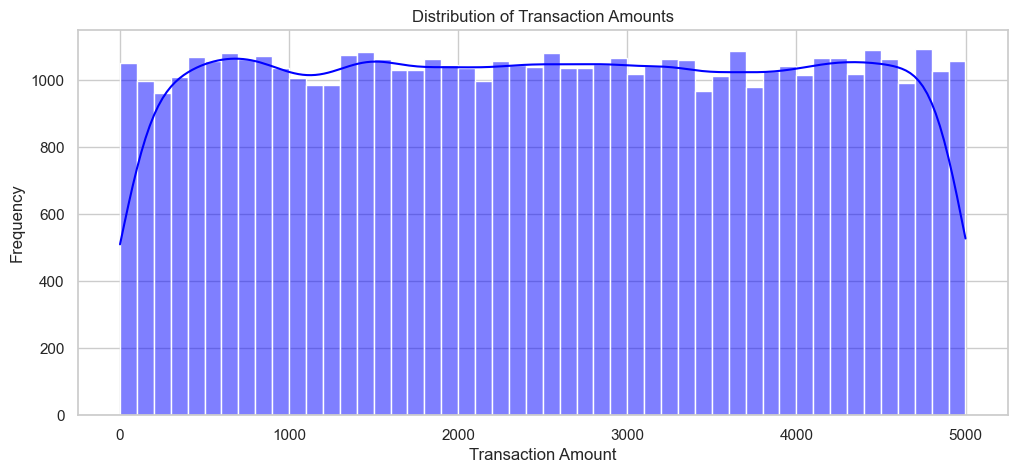

In [24]:
# Distribution of Transaction Amounts
plt.figure(figsize=(12, 5))
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

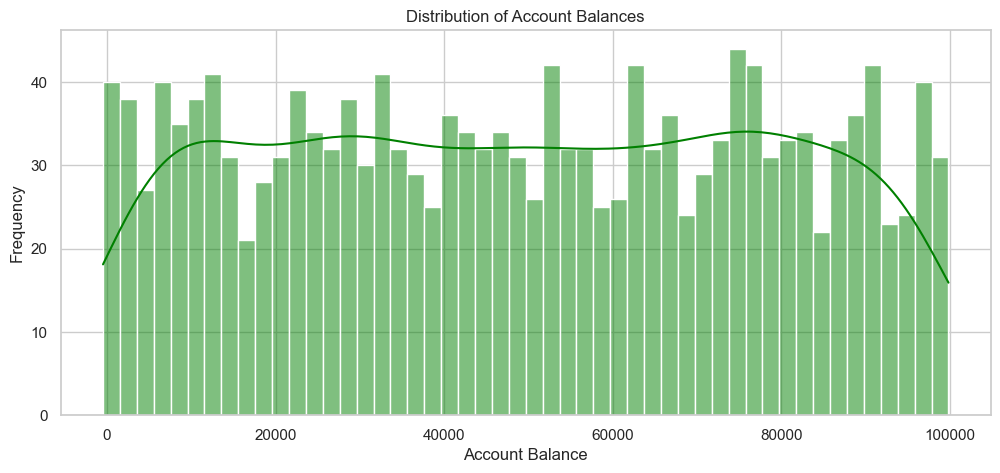

In [25]:
# Distribution of Account Balances
# Since balances repeat per transaction, we group by AccountID to get unique account balances
unique_accounts = df.drop_duplicates(subset=['AccountID'])


plt.figure(figsize=(12, 5))
sns.histplot(unique_accounts['Balance'], bins=50, kde=True, color='green')
plt.title('Distribution of Account Balances')
plt.xlabel('Account Balance')
plt.ylabel('Frequency')
plt.show()

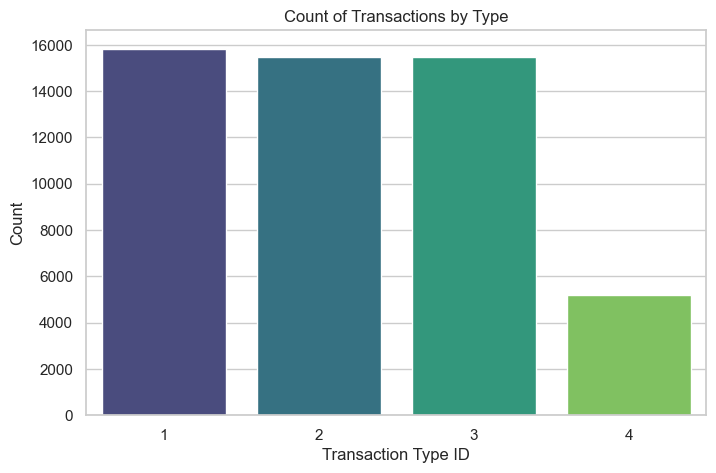

In [26]:
# Count of Transaction Types
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TransactionTypeID', palette='viridis')
plt.title('Count of Transactions by Type')
plt.xlabel('Transaction Type ID')
plt.ylabel('Count')
plt.show()

## 4. Bivariate Analysis
Investigating relationships between variables (e.g., Transaction Amount over time, or by Customer Type).

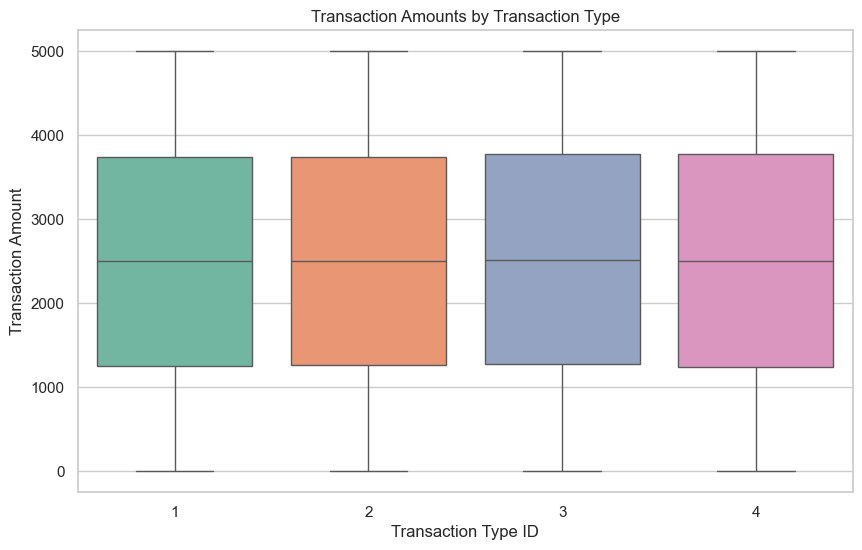

In [27]:
# Transaction Amounts by Transaction Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='TransactionTypeID', y='Amount', palette='Set2')
plt.title('Transaction Amounts by Transaction Type')
plt.xlabel('Transaction Type ID')
plt.ylabel('Transaction Amount')
plt.show()

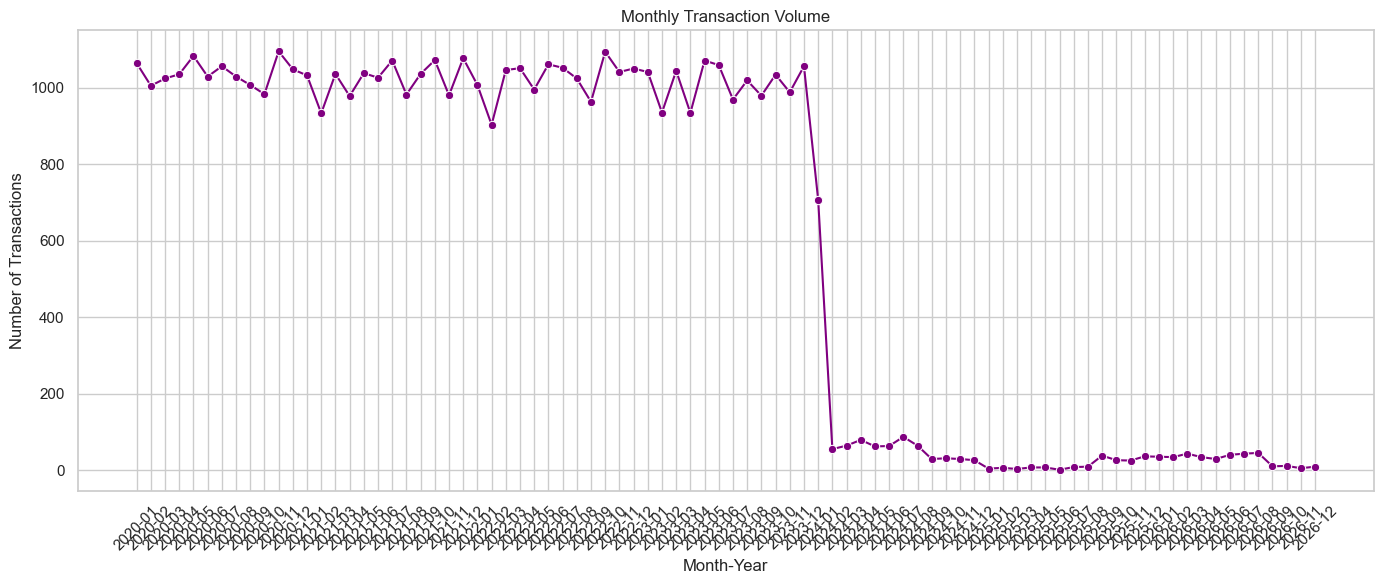

In [28]:
# Transaction Volume Over Time (Monthly)
df_time = df.dropna(subset=['TransactionDate']).copy()
df_time['Month_Year'] = df_time['TransactionDate'].dt.to_period('M')
monthly_counts = df_time.groupby('Month_Year').size().reset_index(name='TransactionCount')
monthly_counts['Month_Year'] = monthly_counts['Month_Year'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_counts, x='Month_Year', y='TransactionCount', marker='o', color='purple')
plt.title('Monthly Transaction Volume')
plt.xlabel('Month-Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Outlier Detection
Identifying anomalies in transaction patterns.

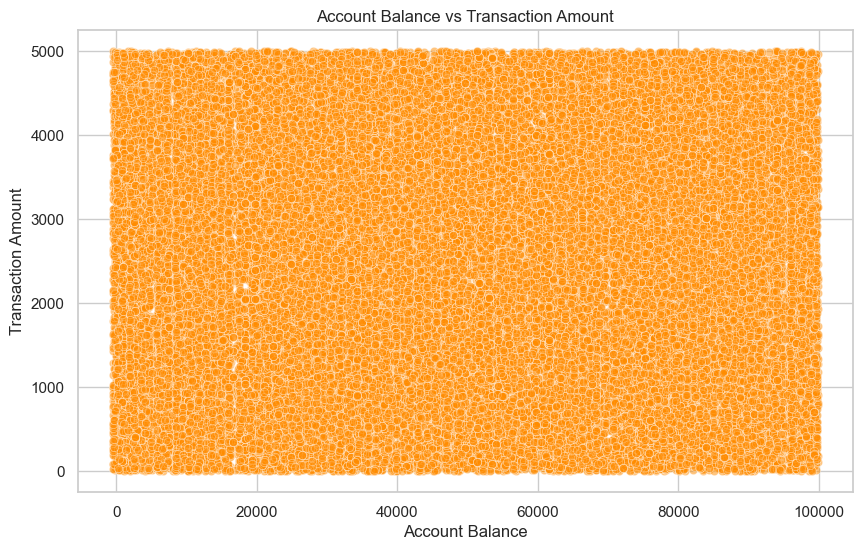

In [29]:
# Scatter plot of Balance vs Transaction Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Balance', y='Amount', alpha=0.5, color='darkorange')
plt.title('Account Balance vs Transaction Amount')
plt.xlabel('Account Balance')
plt.ylabel('Transaction Amount')
plt.show()

## 6. Key Findings / Business Signals
- Record any findings about typical user behavior, unexpected spikes in transaction amounts, or specific transaction types that dominate.